--- Tuning Final KNN Classifier ---
Optimal Parameters: {'metric': 'manhattan', 'n_neighbors': 18, 'weights': 'distance'}

Final Model Accuracy: 0.7480

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.77      0.40      0.52        43
Approved (1)       0.74      0.94      0.83        80

    accuracy                           0.75       123
   macro avg       0.76      0.67      0.68       123
weighted avg       0.75      0.75      0.72       123



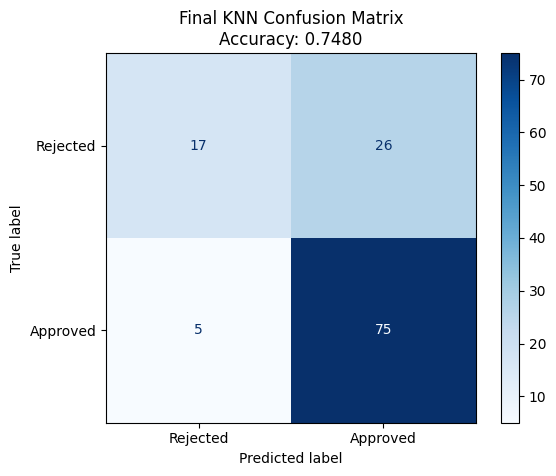

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. Data Preprocessing & Encoding
# ==========================================

# Load dataset
df = pd.read_csv('data.csv')

# Drop the unique identifier column
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# Map target label 'Loan_Status' directly to binary format (1 = Approved, 0 = Rejected)
y = df['Loan_Status'].map({'Y': 1, 'N': 0})
X = df.drop(columns=['Loan_Status'])

# Separate columns by data type
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Handle missing values: median for numbers, mode for categories
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode().iloc[0])

# Use One-Hot Encoding to convert categories into machine-readable binary columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply a moderate SMOTE balancing strategy to fix class imbalance
smote = SMOTE(sampling_strategy=0.8, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Scale features evenly to ensure distance calculations are accurate
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 2. Hyperparameter Tuning & Model Training
# ==========================================

print("--- Tuning Final KNN Classifier ---")

# Define parameter options to find the best configuration
param_grid = {
    'n_neighbors': list(range(5, 25)),
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'euclidean']
}

# Run GridSearch optimizing for Accuracy
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train_balanced)

# Retrieve the optimal model configuration
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)


# ==========================================
# 3. Model Evaluation & Report Generation
# ==========================================

final_accuracy = accuracy_score(y_test, y_pred)
final_cm = confusion_matrix(y_test, y_pred)

print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"\nFinal Model Accuracy: {final_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))


# ==========================================
# 4. Confusion Matrix Visualization
# ==========================================

disp = ConfusionMatrixDisplay(confusion_matrix=final_cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Final KNN Confusion Matrix\nAccuracy: {final_accuracy:.4f}")
plt.show()
